In [1]:
#EJERCICIO 3 REGRESION LASSO SEGUROS
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("E:\Documentos 2\ML y DL\insurance.csv")

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\USER\AppData\Local\Temp\ipykernel_37820\2462803096.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv("E:\Documentos 2\ML y DL\insurance.csv")


In [ ]:
#convertir categoricas a numéricas
df_dummies = pd.get_dummies(df, columns=["sex", "smoker", "region"], drop_first=True)

In [4]:
y = df_dummies["charges"]
X = df_dummies.drop(columns=["charges"])
features = X.columns.tolist()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
modelo = Lasso(alpha=100.0, random_state=42)


In [8]:
modelo.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",100.0
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [10]:
y_pred = modelo.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
print(f"R2: {r2:.3f}")

R2: 0.781


In [11]:
coeficientes = pd.Series(modelo.coef_, index=features).sort_values()
print("\nCoeficientes del modelo (0 = variable descartada por Lasso):")
print(coeficientes.round(2))


Coeficientes del modelo (0 = variable descartada por Lasso):
region_southwest    -104.38
region_southeast     -15.59
sex_male               0.00
region_northwest      -0.00
children             424.98
bmi                 1892.79
age                 3528.80
smoker_yes          9453.07
dtype: float64


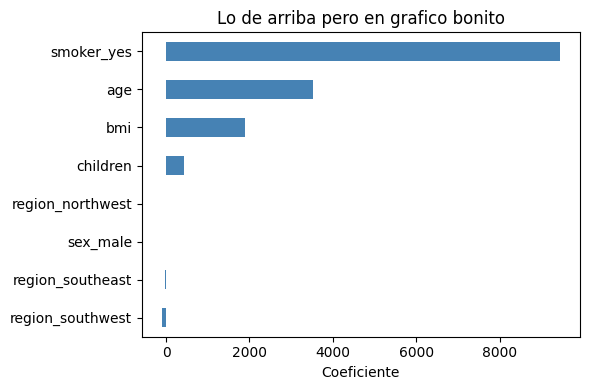

In [13]:
plt.figure(figsize=(6, 4))
coeficientes.plot(kind="barh", color="steelblue")
plt.title("Lo de arriba pero en grafico bonito")
plt.xlabel("Coeficiente")
plt.tight_layout()
plt.show()

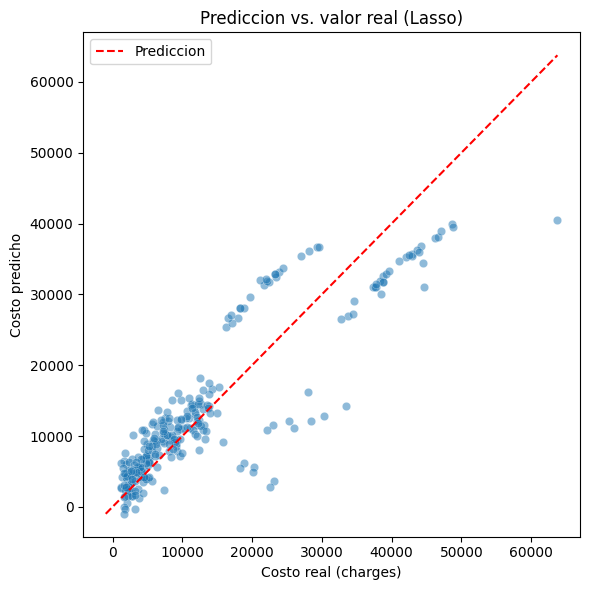

In [15]:
import numpy as np
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors="white", linewidth=0.3)

limite_min = min(y_test.min(), y_pred.min())
limite_max = max(y_test.max(), y_pred.max())
plt.plot([limite_min, limite_max], [limite_min, limite_max],
         color="red", linestyle="--", label="Prediccion")

plt.xlabel("Costo real (charges)")
plt.ylabel("Costo predicho")
plt.title("Prediccion vs. valor real (Lasso)")
plt.legend()
plt.tight_layout()
plt.show()